In [36]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import pickle as pkl
import warnings
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import wandb
from sklearn.metrics import recall_score
import gc
import seaborn as sns

if torch.cuda.is_available():
    torch.device('cuda')
    print("Using the GPU!")

tqdm.pandas()

#test hello

Using the GPU!


In [2]:
train_df = pd.read_csv('~/data/train_df_clean.csv',index_col=0)
test_df = pd.read_csv('~/data/test_df_clean.csv')
dev_df = pd.read_csv('~/data/dev_df_clean.csv')


print(train_df.shape)
print(test_df.shape)
print(dev_df.shape)

(74724, 6)
(23353, 6)
(18682, 6)


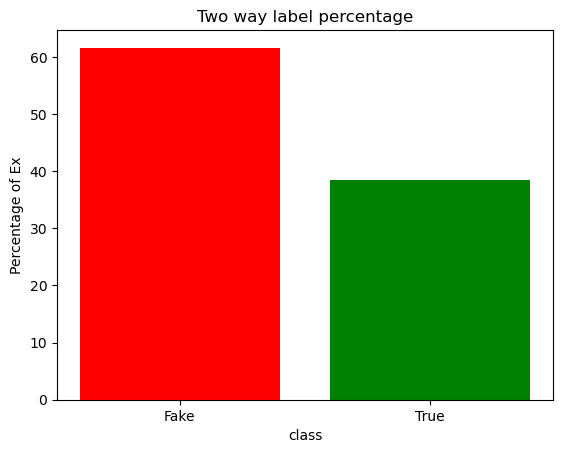

In [72]:
two_lab_agg = pd.DataFrame((train_df.groupby('2_way_label')['2_way_label'].aggregate('count')))
two_lab_agg.columns = ['lab_cnt']
two_lab_agg = two_lab_agg.reset_index()
two_lab_agg['lab_cnt'] = two_lab_agg['lab_cnt'].apply(lambda x: (x/two_lab_agg['lab_cnt'].sum())*100 )

plt.bar(two_lab_agg['2_way_label'],two_lab_agg['lab_cnt'],color=['r','g'])
plt.xticks(ticks=list(set(train_df['2_way_label'])),labels=['Fake','True'])
plt.title('Two way label percentage')
plt.xlabel('class')
plt.ylabel('Percentage of Ex')
plt.savefig('/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/two_way_lab_dist.png',bbox_inches='tight',pad_inches=0.5)
plt.show()

100.0


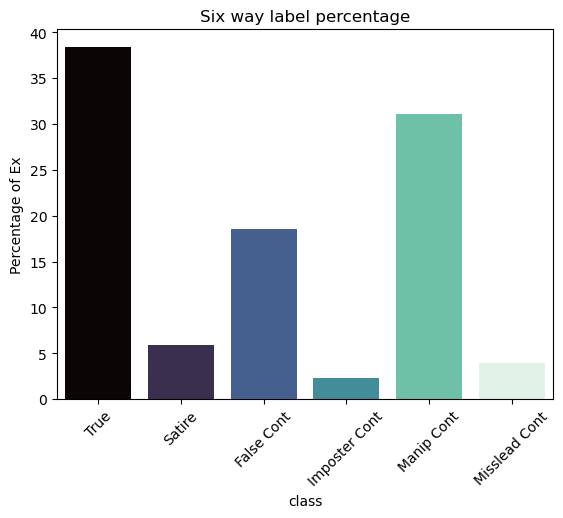

In [73]:
six_lab_agg = pd.DataFrame((train_df.groupby('6_way_label')['6_way_label'].aggregate('count')))
six_lab_agg.columns = ['labs_cnt']
six_lab_agg = six_lab_agg.reset_index()
six_lab_agg['labs_cnt'] = six_lab_agg['labs_cnt'].apply(lambda x: (x/six_lab_agg['labs_cnt'].sum())*100 )
print(six_lab_agg['labs_cnt'].sum())


sns.barplot(data=six_lab_agg,x='6_way_label',y='labs_cnt',hue='6_way_label',palette='mako',legend=False,saturation=0.75)
plt.xticks(ticks=list(set(train_df['6_way_label'])),labels=['True','Satire','False Cont','Imposter Cont','Manip Cont','Misslead Cont'],rotation=45)
plt.title('Six way label percentage')
plt.xlabel('class')
plt.ylabel('Percentage of Ex')
plt.savefig('/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/six_way_lab_dist.png',bbox_inches='tight',pad_inches=0.5)
plt.show()